#### Import

In [ ]:
import os
import json
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#### Upload and unzip dataset

In [ ]:
ZIP_PATH = "generated_icons_v2.zip"
DATA_DIR = "generated_icons_v2"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print(f"Unzipped dataset to: {DATA_DIR}")

Unzipped dataset to: generated_icons_v2


#### Load 4×4 dataset

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "angle_train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "angle_test.csv"))

In [ ]:
pixel_cols = [f"pix{i}" for i in range(16)] # List to store the for 5x5 input data

In [ ]:
X_train = train_df[pixel_cols].values
X_test = test_df[pixel_cols].values

In [ ]:
y_train = train_df["label_id"].values
y_test = test_df["label_id"].values

In [ ]:
class_names = ["cross", "square", "triangle", "x"]

In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train labels:", np.bincount(y_train))
print("Test labels:", np.bincount(y_test))

Train shape: (280, 16)
Test shape: (120, 16)
Train labels: [70 70 70 70]
Test labels: [30 30 30 30]


#### Visualize samples

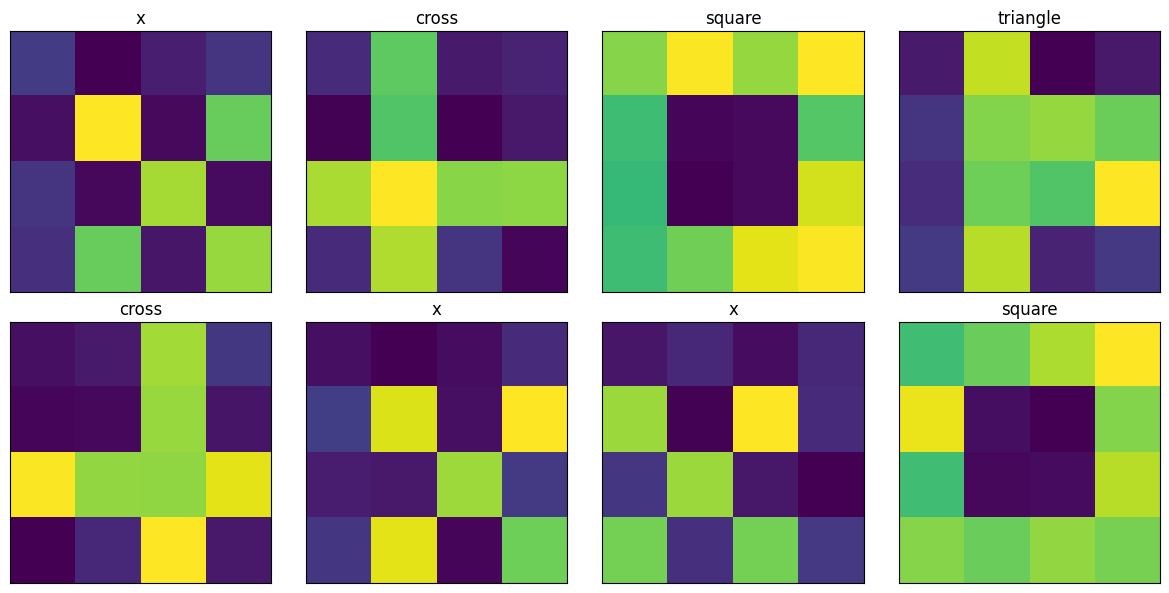

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(12, 6), subplot_kw={"xticks": [], "yticks": []})

for i in range(8):
    ax[i // 4, i % 4].imshow(X_train[i].reshape(4, 4), aspect="equal")
    ax[i // 4, i % 4].set_title(class_names[y_train[i]])

plt.tight_layout()
plt.show()

#### Helper function for evaluation

In [ ]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, class_names):
    start_time = time.time()

    model.fit(X_train, y_train)

    end_time = time.time()
    training_time_sec = end_time - start_time
    training_time_min = training_time_sec / 60

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"\n===== {model_name} =====")
    print(f"Train accuracy: {train_accuracy * 100:.2f}%")
    print(f"Test accuracy: {test_accuracy * 100:.2f}%")
    print(f"Training time: {training_time_sec:.4f} seconds")

    print("\nClassification report:")
    print(classification_report(y_test, y_test_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_test_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    result = {
        "model": model_name,
        "train_accuracy": float(train_accuracy),
        "test_accuracy": float(test_accuracy),
        "training_time_sec": float(training_time_sec),
        "training_time_min": float(training_time_min),
        "input_features": int(X_train.shape[1]),
        "classes": class_names
    }

    return result, y_test_pred

#### 1. Logistic Regression baseline

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Logistic Regression =====
Train accuracy: 98.57%
Test accuracy: 97.50%
Training time: 0.0138 seconds

Classification report:
              precision    recall  f1-score   support

       cross       0.97      0.93      0.95        30
      square       1.00      1.00      1.00        30
    triangle       0.94      0.97      0.95        30
           x       1.00      1.00      1.00        30

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



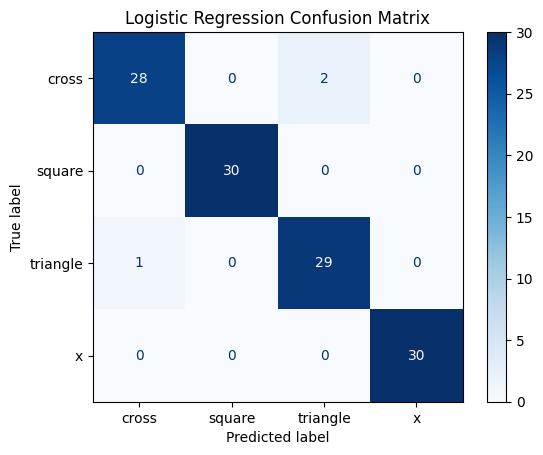

In [ ]:
# Baseline 1: Logistic Regression
log_reg = LogisticRegression(
    max_iter=20,
    random_state=12345,
    solver="lbfgs"
)

log_reg_results, log_reg_pred = evaluate_model(
    log_reg,
    "Logistic Regression",
    X_train,
    y_train,
    X_test,
    y_test,
    class_names
)

#### 2. Small MLP baseline

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and bein


===== Small MLP =====
Train accuracy: 42.50%
Test accuracy: 40.00%
Training time: 0.0369 seconds

Classification report:
              precision    recall  f1-score   support

       cross       0.23      0.53      0.32        30
      square       0.76      0.63      0.69        30
    triangle       0.50      0.43      0.46        30
           x       0.00      0.00      0.00        30

    accuracy                           0.40       120
   macro avg       0.37      0.40      0.37       120
weighted avg       0.37      0.40      0.37       120



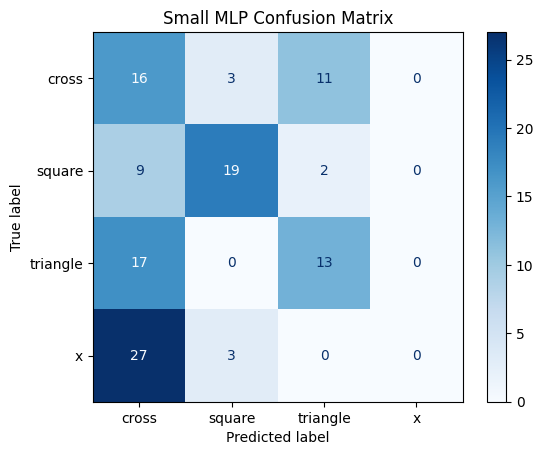

In [ ]:
# Baseline 2: Small MLP
small_mlp = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=20,
    random_state=12345,
    early_stopping=False
)

mlp_results, mlp_pred = evaluate_model(
    small_mlp,
    "Small MLP",
    X_train,
    y_train,
    X_test,
    y_test,
    class_names
)

#### Comparison

In [ ]:
# Compare with QCNN result
qcnn_results = {
    "model": "16-qubit shared-parameter QCNN",
    "train_accuracy": 0.375,
    "test_accuracy": 0.3333,
    "training_time_sec": 120 * 60,  # approximate
    "training_time_min": 120.0,
    "input_features": 16,
    "classes": class_names
}

results = [
    qcnn_results,
    log_reg_results,
    mlp_results
]

results_df = pd.DataFrame(results)

display(results_df[[
    "model",
    "train_accuracy",
    "test_accuracy",
    "training_time_min",
    "input_features"
]])

,model,train_accuracy,test_accuracy,training_time_min,input_features
0,16-qubit shared-parameter QCNN,0.375000,0.3333,120.000000,16
1,Logistic Regression,0.985714,0.9750,0.000230,16
2,Small MLP,0.425000,0.4000,0.000615,16
